# Conversão de `main.py` para Jupyter Notebook

## 1) Imports e configurações iniciais

In [54]:
importlib.reload(utils)
from utils import encontrar_pdfs, regra_divisao, destaca_tabelas
from leitor_pdf import dividir_pdf
import pdfplumber, json
import importlib
import utils
import json

print("Imports carregados")


Imports carregados


## 2) Listar PDFs e iterar sobre eles

In [ ]:
pdf_folder = "arquivos/pastateste"

pdfs_encontrados = [f for f in encontrar_pdfs(pdf_folder) if f.lower().endswith(".pdf")]
print(f"Encontrados {len(pdfs_encontrados)} PDFs em {pdf_folder}")
for arquivo in pdfs_encontrados:
    print("-", arquivo)


## 3) Processar cada PDF (célula principal)

In [ ]:
idx = 0
arquivo = pdfs_encontrados[idx]
print(f"Analisando: {arquivo}")


In [ ]:
def extrair_texto_pagina(pagina):
    largura = pagina.width
    altura = pagina.height-32 # cortar rodapé

    coluna_esquerda = pagina.crop((0, 0, largura/2, altura))
    coluna_direita = pagina.crop((largura/2, 0, largura, altura))

    return coluna_esquerda.extract_text_lines() + coluna_direita.extract_text_lines()
    

In [ ]:
def extrair_tabelas(cropped):
    lines = [
        ((cropped.rects[0]['x0'], cropped.rects[0]['bottom']),(cropped.rects[-2]['x0'], cropped.bbox[-1]-5)), # Linha esquerda
        ((cropped.rect_edges[12]['x0'], cropped.rects[0]['bottom']),(cropped.rect_edges[12]['x0'], cropped.bbox[-1]-5)), # Linha central divisória
        ((cropped.rects[-2]['x0'], cropped.bbox[-1]-5), (cropped.rects[-1]['x1'], cropped.bbox[-1]-5)), # Linha inferior
        ((cropped.rects[-1]['x1']-5, cropped.bbox[-1]-5),(cropped.rects[1]['x1']-5, cropped.rects[1]['bottom'])), # Linha direita
        ((cropped.rects[1]['x1'], cropped.rects[1]['bottom']),(cropped.rects[0]['x0'], cropped.rects[0]['bottom'])) # Linha superior
    ]

    destac_rects = cropped.to_image().draw_lines(lines)
    destac_rects = destac_rects.draw_lines(cropped.rects[2:])

    v_coords = sorted(list(set([
        lines[0][0][0],  # X da Linha esquerda
        lines[1][0][0],  # X da Linha central divisória
        lines[3][0][0]   # X da Linha direita
    ])))

    h_coords = sorted(list(set(
        [lines[4][0][1], lines[2][0][1]] + # Linha superior e inferior do desenho
        [r["top"] for r in cropped.rects[2:]] + # Topo de cada linha de dado
        [r["bottom"] for r in cropped.rects[2:]] # Base de cada linha de dado
    )))

    table_settings = {
        "vertical_strategy": "explicit",
        "explicit_vertical_lines": v_coords,
        
        # Agora usamos estratégia explícita também para o horizontal
        "horizontal_strategy": "explicit", 
        "explicit_horizontal_lines": h_coords,
        
        "snap_y_tolerance": 6,
        "join_tolerance": 5,
    }

    return cropped.extract_table(table_settings=table_settings)

In [66]:
importlib.reload(utils)
import math
from utils import ajustar_linha, filtrar_e_ajustar_h_lines
def tabela_extrator(cropped):
   v_coords = sorted(list(set([
      cropped.bbox[0],              
      cropped.bbox[2]               
   ])))

   table_settings_lines = {
      "horizontal_strategy": "text", 
      "snap_y_tolerance": 4,
      "join_tolerance": 5,
      "min_words_vertical": 1
   }

   finder = cropped.debug_tablefinder(table_settings=table_settings_lines)
   
   hlines_tops = [int(line['top']) for line in finder.edges]

   for i, line in enumerate(hlines_tops):
      if i > 0 and i < (len(hlines_tops)-1) and math.isclose((hlines_tops[i+1] - line), (line - hlines_tops[i-1]), rel_tol=0.2):
            hlines_tops.pop(i)

   words = cropped.extract_words()
   h_coords_limpas = filtrar_e_ajustar_h_lines(hlines_tops, words)

   table_settings_cols = {
      "vertical_strategy": "text", 
      "snap_y_tolerance": 4,
      "join_tolerance": 5,
      "min_words_vertical": 1
   }

   finder = cropped.debug_tablefinder(table_settings=table_settings_cols)
   
   vlines_tops = [int(line['x0']) for line in finder.edges]
   
   for i, line in enumerate(vlines_tops):
      if i > 0 and i < (len(vlines_tops)-1):
            if ((vlines_tops[i+1] - line) < 20):
               vlines_tops.pop(i)

   words = cropped.extract_text_lines()
   
   lines = [i for i in range(0, round(cropped.width), round(cropped.width/7))]
   linhas_ajustadas = [ajustar_linha(l, words, 100) for l in lines]
   linhas_ajustadas.append(cropped.extract_text_lines()[-2]['x1'])
   
   table_settings = {
      "vertical_strategy": "explicit",
      "explicit_vertical_lines": linhas_ajustadas,
      "horizontal_strategy": "explicit", 
      "explicit_horizontal_lines": h_coords_limpas,
      "snap_y_tolerance": 4,
      "join_tolerance": 5,
   }

   pag_tables = cropped.extract_tables(table_settings=table_settings)

   return cropped, pag_tables, table_settings


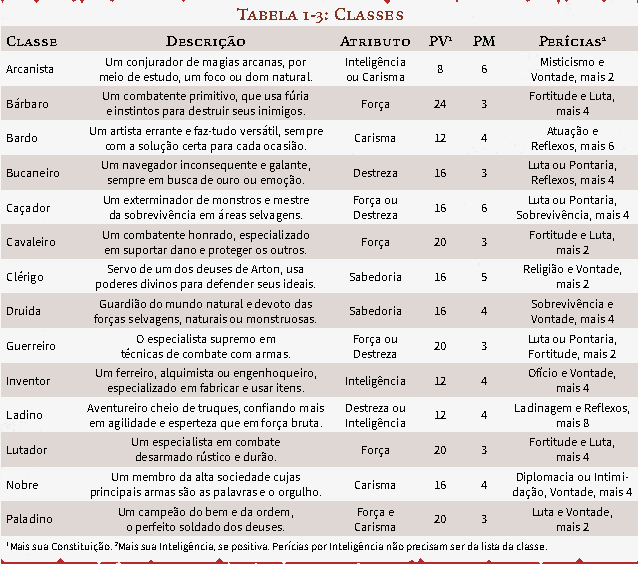

object_type,page_number,x0,x1,y0,y1,doctop,top,bottom,width,height,adv,bits,colorspace,dash,evenodd,fill,fontname,imagemask,linewidth,matrix,mcid,name,ncs,non_stroking_color,path,pts,size,srcsize,stream,stroke,stroking_color,tag,text,upright
image,38,51.023999999999994,510.2358,-15.3561928,794.8837891,29150.76639999998,308.23040000000003,714.4461,459.2118,406.21569999999997,,8,"[['ICCBased', {'rawdata': 'JettfkGzChWJhbc5IJFzNO4I8ow8/UR5SvN6h9OgXX4LdiSZuKYFr0yAIYzeFp6AcmFitw8/EyDb4lu/vNGpUmDCs8ydKSlXiEdxygvYqzUMwOKI/IloEqGitduAIC6bmlSYHFd+0n5wVwk35wUJuHHEv2kBYIbhvtRjv0yOJPpUygEg8gWexnd/f+I3kxd0Isr8nsGs5IGhwiBxl2YmOftwy0QNfTjtvsAGFKq3XtkibAFKd2xknyyTjWsno5lJiffTdsrK/UB8PtzITnjFmd+IUCTa9BZK84jTctRKUsyuGPi+pHfhg6+VM5DtABa0IT9ma3mU6AVpgeyb9TXQLqfRz5lf1S4+i/xWU2jdQV6iuIzW8sWOn4Qj2/IcV/1z1tb61KQdMRgVPsklMy5RclECqL6svJJFuEBRUvXEyiBSIRk/6pRkVR8gmZp9s5lI81AAM0IZ8mBS6XRWyC/ImoLP5bsXKocLSxP/tPbWKE86LFQKgHwd6HtnNcJfd2qMke+WkpmBn4E9Au9GLJD8t45oXSotX7aioNjW4dcAmkTmp2imRvmO15hVQRaRJk1RGOR2ZepwvINFRvo/

In [ ]:
from tablecv import extract_table
df = extract_table(image_path="your_image.png")   
with pdfplumber.open(arquivo) as pdf:
        # for pagina_idx, page in enumerate(pdf.pages):
                page = pdf.pages[37]
                
                pagina_completa = extrair_texto_pagina(page)
                tem_tabela = False
                nomesTabelas=[]
                for linha in pagina_completa:
                        if "Tabela" in linha['text']: 
                                tem_tabela=True

                        
                if tem_tabela: 
                        cropped = extrair_tabela_por_linhas_vermelhas(page)
                        if cropped != None: 
                                display(cropped.to_image(100))

                                print(cropped.to_csv())

<Page:38>


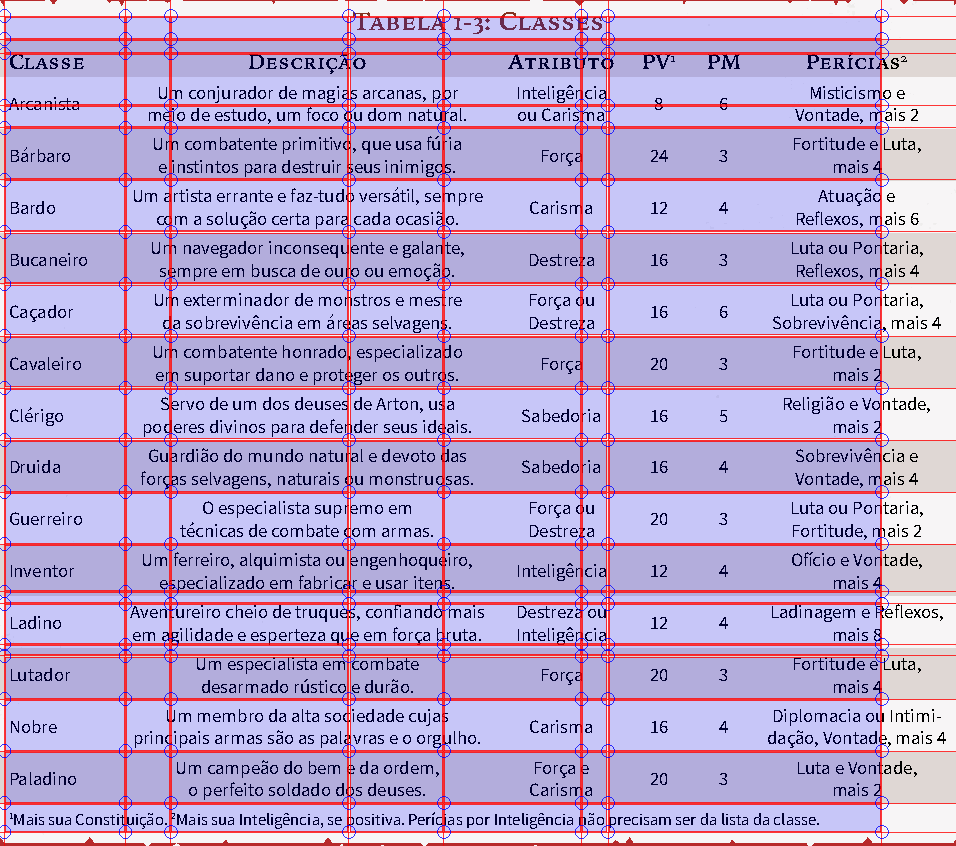

Tabela 1-3: Classes


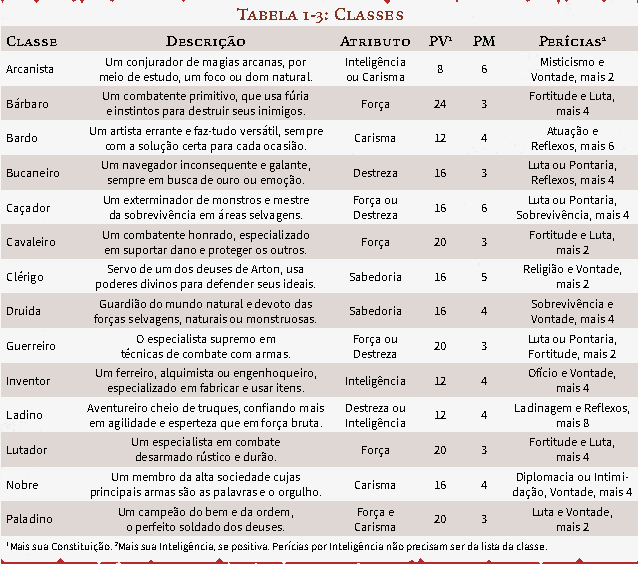

[['Classe Descrição Atributo', 'PV1 PM Perícias2'], ['Um conjurador de magias arcanas, por Inteligência\nArcanista\nmeio de estudo, um foco ou dom natural. ou Carisma', 'Misticismo e\n8 6\nVontade, mais 2'], ['Um combatente primitivo, que usa fúria\nBárbaro Força\ne instintos para destruir seus inimigos.', 'Fortitude e Luta,\n24 3\nmais 4'], ['Um artista errante e faz-tudo versátil, sempre\nBardo Carisma\ncom a solução certa para cada ocasião.', 'Atuação e\n12 4\nReflexos, mais 6'], ['Um navegador inconsequente e galante,\nBucaneiro Destreza\nsempre em busca de ouro ou emoção.', 'Luta ou Pontaria,\n16 3\nReflexos, mais 4'], ['Um exterminador de monstros e mestre Força ou\nCaçador\nda sobrevivência em áreas selvagens. Destreza', 'Luta ou Pontaria,\n16 6\nSobrevivência, mais 4'], ['Um combatente honrado, especializado\nCavaleiro Força\nem suportar dano e proteger os outros.', 'Fortitude e Luta,\n20 3\nmais 2'], ['Servo de um dos deuses de Arton, usa\nClérigo Sabedoria\npoderes divinos pa

In [67]:
from IPython.display import display


with pdfplumber.open(arquivo) as pdf:
        # for pagina_idx, page in enumerate(pdf.pages):
                page = pdf.pages[37]
                pagina_completa = extrair_texto_pagina(page)
                tem_tabela = False
                nomesTabelas=[]
                for linha in pagina_completa:
                        if "Tabela" in linha['text']: 
                                tem_tabela=True

                        
                if tem_tabela: 
                        cropped = extrair_tabela_por_linhas_vermelhas(page)
                        if cropped != None: 
                                print(page)
                                t, pt, ts = tabela_extrator(cropped)
                                display(t.to_image(150).debug_tablefinder(table_settings=ts))
                                for linha in cropped.extract_text_lines():
                                        if "Tabela" in linha['text']:
                                                nomesTabelas.append(linha['text'])
                                                print(linha['text'])
                                                table = extrair_tabelas(cropped)
                                                # with open(f"{linha['text']}.json", 'w', encoding='utf-8') as f:
                                                #         json.dump({tab[0]: tab[1].replace('\n', ' ') for tab in table}, f, ensure_ascii=False)
                                display(cropped.to_image(100))
                                print(table)
                                print("\n")

In [ ]:
racas = {raca[0]: raca[1].replace('\n', ' ') for raca in table}
with open('racas.json', 'w', encoding='utf-8') as racas_json:
    json.dump(racas, racas_json, indent=4, ensure_ascii=False)
    print(racas)
    print(json.dumps(racas, ensure_ascii=False))

In [ ]:
# Iterar sobre as linhas extraídas e detectar padrões
largura = page.width
altura = page.height-32 # cortar rodapé

coluna_esquerda = page.crop((0, 0, largura/2, altura))
coluna_direita = page.crop((largura/2, 0, largura, altura))

pagina_completa = coluna_esquerda.extract_text_lines() + coluna_direita.extract_text_lines()

for linha in pagina_completa:
    R, G, B = (
        linha["chars"][0]["non_stroking_color"][0],
        linha["chars"][0]["non_stroking_color"][1],
        linha["chars"][0]["non_stroking_color"][2],
    )
    tam_fonte = linha["chars"][0]["size"]

    params_title = all(pixel_color * 255 > 200 for pixel_color in (R, G, B)) and tam_fonte >= 15

    # if "Tabela" in linha["text"]:
    #     list_tabela = Tabela(linha["text"], tam_fonte, [R, G, B])
    #     print(linha["chars"][0])

    if params_title: print(linha['text']) 
    # if (params_title):
    #     print(linha['text'])
    #     print(tam_fonte)

